# Load and plot image

This starter notebook does three things: load a file, get image data, and plot it with Matplotlib. Matplotlib is used only in documentation/notebook examples, not in the CloudScope runtime dependencies.

In [1]:
import matplotlib.pyplot as plt

from acqstore.sample_data import ensure_sample
from acqstore.acq_image import AcqImageList

## Load sample data

Use `cloudscope-data` sample data for a reproducible first run. Replace this with a local `.oir`, `.czi`, `.tif`, or `.ome.zarr` path when adapting the notebook.

In [2]:
sample_folder = ensure_sample("demo-small")
acq_list = AcqImageList(str(sample_folder))

acq = acq_list.get_files()[0]
print(acq.name)

header = acq.images.header
for k, v in header.as_dict().items():
    print(f"{k}: {v}")


20251030_A106_0002.oir
path: /Users/cudmore/Library/Application Support/cloudscope/sample-data/demo-small-v1/demo-small/cond1/20251030_A106_0002.oir
shape: (30000, 24)
dims: ('Y', 'X')
sizes: {'Y': 30000, 'X': 24}
dtype: uint16
num_channels: 1
num_scenes: 1
physical_units: (0.0005350211513449023, 0.011413784562024583)
physical_units_labels: ('Y', 'X')
date: 20251030
time: 14:54:36
file_size: 5.9 MB


## Get image data

This example asks the file loader for a single 2D plane.

In [3]:
channel_indices = acq.images.channel_indices
channel = channel_indices[0]
image = acq.images.get_slice_data(channel=channel, z=0, t=0)
print("channels:", channel_indices)
print(image.shape, image.dtype, image.min(), image.max())

channels: [0]
(30000, 24) uint16 25 998


## Plot with Matplotlib

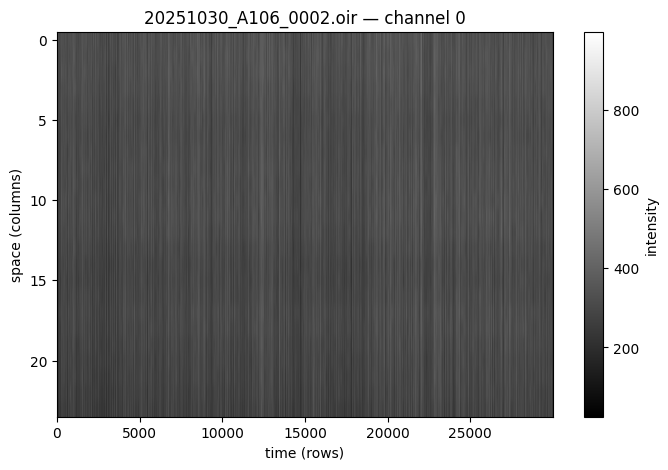

In [4]:
# This is a line-scan kymograph (here 30000 time rows x 24 spatial columns).
# image.T puts time on the x axis and space on the y axis. Such a wide/short
# array is invisible with imshow's default aspect="equal" (square pixels), so we
# use aspect="auto" to fill the axes box.
plt.figure(figsize=(8, 5))
plt.imshow(image.T, cmap="gray", aspect="auto")
plt.title(f"{acq.name} — channel {channel}")
plt.xlabel("time (rows)")
plt.ylabel("space (columns)")
plt.colorbar(label="intensity");